# Cyclic (irregular cycles)

Cyclic series oscillate, but — unlike a clean seasonal wave — with *irregular* periods and amplitudes: business cycles, ecological booms and busts, quasi-periodic signals. The generator overlays one or more noisy cycles so the period drifts rather than repeating exactly.

::: {.callout-note}
## The model

$$y_t = \text{base} + \text{trend}\cdot t + \sum_{i=1}^{n} A_i \sin\!\big(\psi_i(t)\big) + \varepsilon_t$$

Each series superimposes `num_cycles` oscillations whose periods vary from cycle to cycle (`cycle_period_std` controls how irregular). Small variance approaches a fixed seasonal wave; large variance produces genuinely aperiodic cycling.
:::

In [ ]:
import polars as pl
import matplotlib.pyplot as plt

from synforecast.generators import CyclicGenerator

## 1. Cycle length

`cycle_period_mean` sets the average cycle length in steps. The period still drifts within each series, which is what separates a cycle from a fixed seasonal wave.


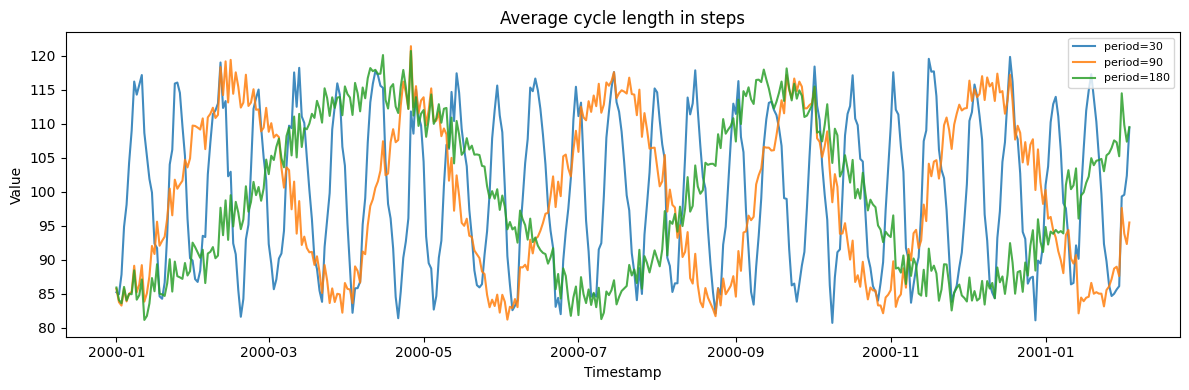

In [ ]:
base = {
    "min_length": 400,
    "max_length": 400,
    "freq": "D",
    "base_level": 100.0,
    "trend": 0.0,
    "cycle_amplitude_mean": 20.0,
    "num_cycles": 1,
    "noise_std": 2.0,
    "seed": 42,
}

fig, ax = plt.subplots(figsize=(12, 4))
for period in (30.0, 90.0, 180.0):
    df = CyclicGenerator(
        engine="polars", cycle_period_mean=period, **base
    ).generate(n_series=1)
    ax.plot(df["ds"].to_list(), df["y"].to_list(), label=f"period={period:.0f}", alpha=0.85)
ax.set(xlabel="Timestamp", ylabel="Value", title="Average cycle length in steps")
ax.legend(fontsize=8)
plt.tight_layout()
plt.show()


## 2. Cycle irregularity

`cycle_period_std` controls how much the period wanders. At zero the series is close to a fixed seasonal wave; large values give genuinely aperiodic cycling.


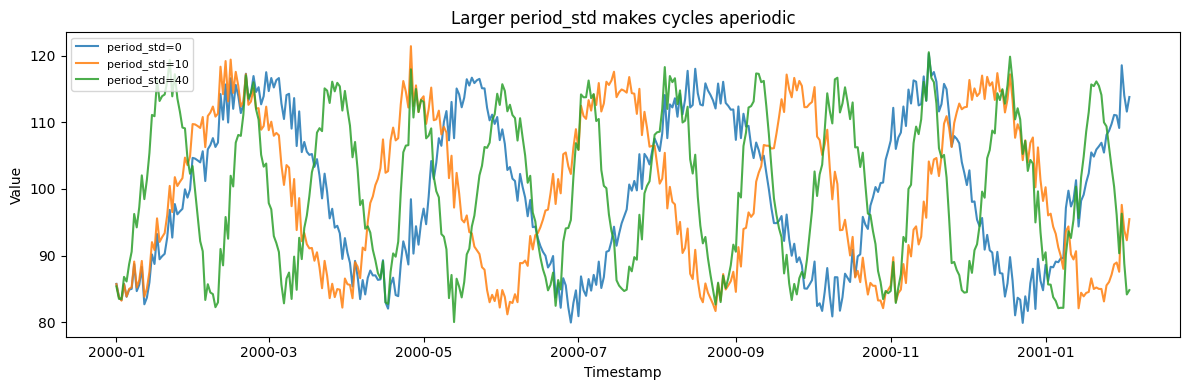

In [ ]:
fig, ax = plt.subplots(figsize=(12, 4))
for period_std in (0.0, 10.0, 40.0):
    df = CyclicGenerator(
        engine="polars",
        min_length=400,
        max_length=400,
        freq="D",
        base_level=100.0,
        trend=0.0,
        cycle_period_mean=90.0,
        cycle_period_std=period_std,
        cycle_amplitude_mean=20.0,
        num_cycles=1,
        noise_std=2.0,
        seed=42,
    ).generate(n_series=1)
    ax.plot(
        df["ds"].to_list(), df["y"].to_list(), label=f"period_std={period_std:.0f}", alpha=0.85
    )
ax.set(xlabel="Timestamp", ylabel="Value", title="Larger period_std makes cycles aperiodic")
ax.legend(fontsize=8)
plt.tight_layout()
plt.show()


## 3. Negative trend

A downward trend combined with cyclical fluctuations.

In [ ]:
declining_params = {
    "min_length": 300,
    "max_length": 300,
    "freq": "D",
    "base_level": 150.0,
    "trend": -0.05,
    "cycle_period_mean": 50.0,
    "cycle_amplitude_mean": 20.0,
    "num_cycles": 3,
    "seed": 42,
}

declining_gen = CyclicGenerator(engine="polars", **declining_params)
declining_df = declining_gen.generate(n_series=1)

print(f"Generated {len(declining_df)} observations with declining trend")
print(f"Statistics: Mean={declining_df['y'].mean():.4f}, Std={declining_df['y'].std():.4f}")
declining_df.head(10)

Generated 300 observations with declining trend
Statistics: Mean=140.8307, Std=27.3867


unique_id,ds,y
cat,datetime[ns],f64
"""0""",2000-01-01 00:00:00,143.101924
"""0""",2000-01-02 00:00:00,141.627292
"""0""",2000-01-03 00:00:00,136.638082
"""0""",2000-01-04 00:00:00,134.529648
"""0""",2000-01-05 00:00:00,133.656044
"""0""",2000-01-06 00:00:00,129.039617
"""0""",2000-01-07 00:00:00,128.071289
"""0""",2000-01-08 00:00:00,128.080343
"""0""",2000-01-09 00:00:00,129.365766


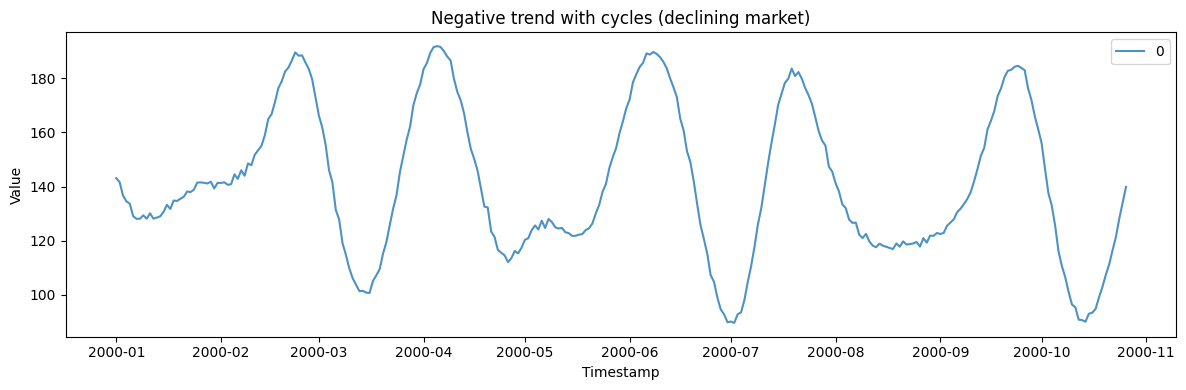

In [ ]:
fig, ax = plt.subplots(figsize=(12, 4))
for uid in declining_df["unique_id"].unique().to_list():
    series = declining_df.filter(pl.col("unique_id") == uid)
    ax.plot(series["ds"].to_list(), series["y"].to_list(), label=uid, alpha=0.8)
ax.set_xlabel("Timestamp")
ax.set_ylabel("Value")
ax.set_title("Negative trend with cycles (declining market)")
ax.legend()
plt.tight_layout()
plt.show()

## 4. Overlapping cycles

Five overlapping cycle components create a complex, realistic pattern.

In [ ]:
complex_params = {
    "min_length": 500,
    "max_length": 500,
    "freq": "D",
    "base_level": 100.0,
    "trend": 0.02,
    "cycle_period_mean": 60.0,
    "cycle_amplitude_mean": 15.0,
    "num_cycles": 5,
    "seed": 42,
}

complex_gen = CyclicGenerator(engine="polars", **complex_params)
complex_df = complex_gen.generate(n_series=1)

print(f"Generated {len(complex_df)} observations with multiple overlapping cycles")
print(f"Statistics: Mean={complex_df['y'].mean():.4f}, Std={complex_df['y'].std():.4f}")
complex_df.head(10)

Generated 500 observations with multiple overlapping cycles
Statistics: Mean=105.8392, Std=43.9463


unique_id,ds,y
cat,datetime[ns],f64
"""0""",2000-01-01 00:00:00,126.751732
"""0""",2000-01-02 00:00:00,127.885824
"""0""",2000-01-03 00:00:00,129.749177
"""0""",2000-01-04 00:00:00,128.563635
"""0""",2000-01-05 00:00:00,130.119181
"""0""",2000-01-06 00:00:00,127.31363
"""0""",2000-01-07 00:00:00,126.418862
"""0""",2000-01-08 00:00:00,125.266044
"""0""",2000-01-09 00:00:00,124.954641


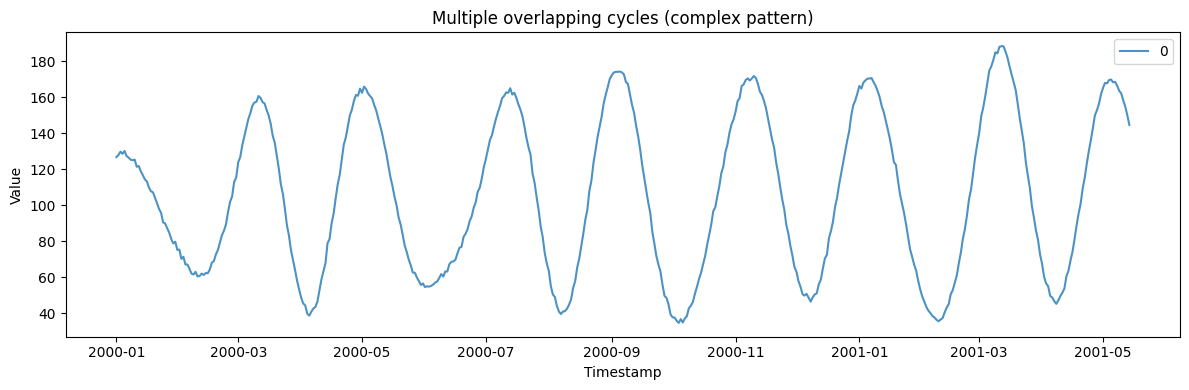

In [ ]:
fig, ax = plt.subplots(figsize=(12, 4))
for uid in complex_df["unique_id"].unique().to_list():
    series = complex_df.filter(pl.col("unique_id") == uid)
    ax.plot(series["ds"].to_list(), series["y"].to_list(), label=uid, alpha=0.8)
ax.set_xlabel("Timestamp")
ax.set_ylabel("Value")
ax.set_title("Multiple overlapping cycles (complex pattern)")
ax.legend()
plt.tight_layout()
plt.show()

## 5. Multiple series

Generate multiple independent cyclic series in one call.

In [ ]:
multi_params = {
    "min_length": 200,
    "max_length": 200,
    "freq": "D",
    "base_level": 100.0,
    "trend": 0.03,
    "cycle_period_mean": 60.0,
    "cycle_amplitude_mean": 20.0,
    "num_cycles": 3,
    "seed": 42,
}

multi_gen = CyclicGenerator(engine="polars", **multi_params)
multi_df = multi_gen.generate(n_series=3)

print(f"Generated 3 series with {len(multi_df)} total observations")
print(f"Overall Statistics: Mean={multi_df['y'].mean():.4f}, Std={multi_df['y'].std():.4f}")
multi_df.filter(pl.col("unique_id") == "0").head(10)

Generated 3 series with 600 total observations
Overall Statistics: Mean=103.3095, Std=24.7829


unique_id,ds,y
cat,datetime[ns],f64
"""0""",2000-01-01 00:00:00,93.663885
"""0""",2000-01-02 00:00:00,92.67384
"""0""",2000-01-03 00:00:00,88.006548
"""0""",2000-01-04 00:00:00,86.059544
"""0""",2000-01-05 00:00:00,85.195164
"""0""",2000-01-06 00:00:00,80.448824
"""0""",2000-01-07 00:00:00,79.228091
"""0""",2000-01-08 00:00:00,78.881414
"""0""",2000-01-09 00:00:00,79.728552


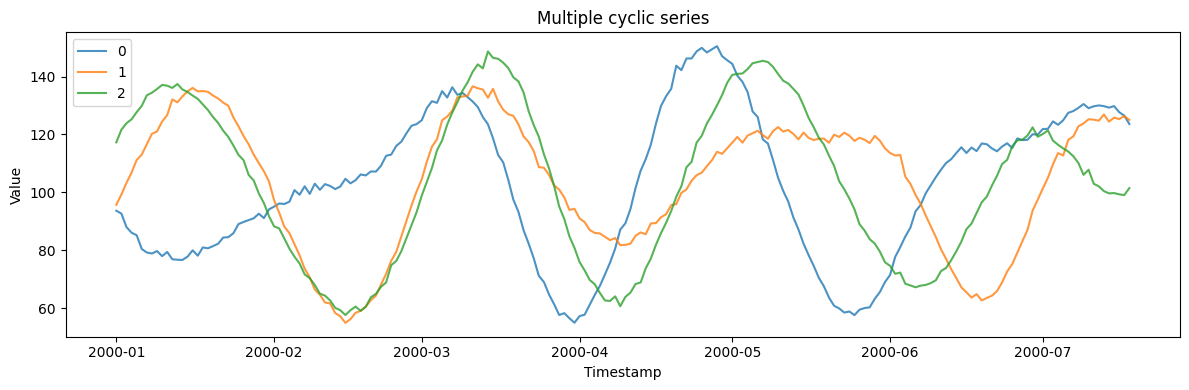

In [ ]:
fig, ax = plt.subplots(figsize=(12, 4))
for uid in multi_df["unique_id"].unique().to_list():
    series = multi_df.filter(pl.col("unique_id") == uid)
    ax.plot(series["ds"].to_list(), series["y"].to_list(), label=uid, alpha=0.8)
ax.set_xlabel("Timestamp")
ax.set_ylabel("Value")
ax.set_title("Multiple cyclic series")
ax.legend()
plt.tight_layout()
plt.show()

::: {.callout-tip}
## Related generators

- [Seasonal](../statistical/seasonal) — a fixed, exactly repeating period.
- [Gaussian process](../multivariate/gaussian_process) — periodic kernels for smooth quasi-periodicity.

Cycle-count and irregularity parameters are in the [generator reference](https://github.com/Nixtla/synforecast/blob/main/GENERATORS.md).
:::